# 03 — Model A: Custom CNN Baseline

**Day:** 3 of the project plan
**Goal:** train a small CNN *from scratch* on the 70/15/15 splits we built in Day 2.
This sets the floor every later model has to beat.

> **GPU is required for full training.** On CPU the full 25-epoch run takes hours;
> on a Colab T4 it finishes in ~10-15 minutes. The first cell after setup checks
> the active device and prints a warning if no GPU is visible.

> **Limitation reminder:** the dataset is augmented and upsampled. Image-level
> splitting can leak near-duplicates across train / val / test, inflating test
> accuracy. We treat all numbers as a comparison between architectures, not a
> clinical estimate. This caveat is repeated in every later notebook.


## 0. Environment setup

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "torch")

def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import google.colab; IN_COLAB = True
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB, "  Keras backend:", os.environ["KERAS_BACKEND"])


In Colab: False   Keras backend: torch


In [2]:
from src.config import (summary, set_global_seed, BATCH_SIZE, IMG_SIZE,
                          IMG_CHANNELS, NUM_CLASSES, CLASS_NAMES)
from src.training import configure_gpu
print(summary())
set_global_seed()
gpu_info = configure_gpu()
print("Device info:", gpu_info)
if gpu_info["device"] != "GPU":
    print("\n*** WARNING: no GPU detected. Full training on CPU is impractical. ***")
    print("    On Colab: Runtime -> Change runtime type -> GPU.")
    print("    Locally on Windows: TF needs WSL2 for GPU.")


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42



Device info: {'backend': 'torch', 'gpus': ['NVIDIA GeForce RTX 5080'], 'device': 'GPU', 'keras_version': '3.14.0', 'torch_version': '2.11.0+cu128', 'cuda': '12.8', 'compute_capability': [12, 0]}


## 1. Load the splits and build the data pipeline

We load the CSVs written by `02_data_preprocessing.ipynb` and turn them into `tf.data.Dataset`s.
Training gets light augmentation; val and test are clean.

In [3]:
from src.io_utils import load_split, make_tf_dataset

train_df = load_split("train")
val_df   = load_split("val")
test_df  = load_split("test")
print(f"train: {len(train_df):,}   val: {len(val_df):,}   test: {len(test_df):,}")

train_ds = make_tf_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True,  augment=True)
val_ds   = make_tf_dataset(val_df,   batch_size=BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_tf_dataset(test_df,  batch_size=BATCH_SIZE, shuffle=False, augment=False)


train: 30,799   val: 6,600   test: 6,601


## 2. Build the model

Architecture (matches Day 3, Step 3.1 of the project plan):

| Block | Layers |
|---|---|
| Conv block 1 | Conv(32, 3×3, same) → BN → ReLU → MaxPool 2×2 |
| Conv block 2 | Conv(64, 3×3, same) → BN → ReLU → MaxPool 2×2 |
| Conv block 3 | Conv(128, 3×3, same) → BN → ReLU → MaxPool 2×2 |
| Conv block 4 | Conv(256, 3×3, same) → BN → ReLU → MaxPool 2×2 |
| Head | GlobalAveragePooling → Dense(128, ReLU) → Dropout(0.3) → Dense(4, softmax) |

GAP instead of Flatten keeps the parameter count low (~423k) so we can train from
scratch without the model overfitting on day one.


In [4]:
from src.models import build_baseline_cnn
model = build_baseline_cnn()
model.summary(line_length=110)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                             │ (None, 128, 128, 3)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ augment (Sequential)                           │ (None, 128, 128, 3)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d (Conv2D)                                │ (None, 128, 128, 32)                │                 864 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ batch_normalization (BatchNormalization)       │ (None, 128, 128, 32)                │                 128 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ activation (Activation)                        │ (None, 128, 128, 32)                │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ max_pooling2d (MaxPooling2D)                   │ (None, 64, 64, 32)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_1 (Conv2D)                              │ (None, 64, 64, 64)                  │              18,432 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ batch_normalization_1 (BatchNormalization)     │ (None, 64, 64, 64)                  │                 256 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ activation_1 (Activation)                      │ (None, 64, 64, 64)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ max_pooling2d_1 (MaxPooling2D)                 │ (None, 32, 32, 64)                  │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_2 (Conv2D)                              │ (None, 32, 32, 128)                 │              73,728 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ batch_normalization_2 (BatchNormalization)     │ (None, 32, 32, 128)                 │                 512 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ activation_2 (Activation)                      │ (None, 32, 32, 128)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ max_pooling2d_2 (MaxPooling2D)                 │ (None, 16, 16, 128)                 │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_3 (Conv2D)                              │ (None, 16, 16, 256)                 │             294,912 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ batch_normalization_3 (BatchNormalization)     │ (None, 16, 16, 256)                 │               1,024 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ activation_3 (Activation)                      │ (None, 16, 16, 256)                 │                   0 │
├───

 Total params: 423,268 (1.61 MB)

 Trainable params: 422,308 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 3. Training settings

| Knob | Value |
|---|---|
| optimizer | Adam |
| learning rate | 1e-3 |
| batch size | 32 |
| epochs | 30 (capped) |
| EarlyStopping | `monitor="val_accuracy", patience=5, restore_best_weights=True` |
| ReduceLROnPlateau | `factor=0.5, patience=2, min_lr=1e-6` |
| ModelCheckpoint | best-only, saved at `outputs/models/baseline_cnn.keras` |

> **Smoke vs full mode.** If you don't have a GPU, set `EPOCHS = 2` and `SAMPLE_FRAC = 0.02` to do
> a 1-minute smoke test on a tiny subset just to verify the pipeline. Otherwise leave them at the
> full values for a real training run.


In [5]:
# Toggle between smoke (CPU-friendly) and full (GPU) modes
SMOKE = (gpu_info["device"] != "GPU")
EPOCHS = 2 if SMOKE else 30
SAMPLE_FRAC = 0.02 if SMOKE else 1.0
# Optional env override for quick CI-style verification on GPU machines
if "OVERRIDE_EPOCHS" in os.environ:
    EPOCHS = int(os.environ["OVERRIDE_EPOCHS"])
if "OVERRIDE_SAMPLE_FRAC" in os.environ:
    SAMPLE_FRAC = float(os.environ["OVERRIDE_SAMPLE_FRAC"])
print(f"Mode: {'SMOKE' if SMOKE else 'FULL'}   epochs={EPOCHS}   sample_frac={SAMPLE_FRAC}")


Mode: FULL   epochs=30   sample_frac=1.0


In [6]:
if SAMPLE_FRAC < 1.0:
    train_df_used = train_df.sample(frac=SAMPLE_FRAC, random_state=42)
    val_df_used   = val_df.sample(frac=SAMPLE_FRAC, random_state=42)
    test_df_used  = test_df.sample(frac=SAMPLE_FRAC, random_state=42)
    train_ds = make_tf_dataset(train_df_used, batch_size=BATCH_SIZE, shuffle=True,  augment=True)
    val_ds   = make_tf_dataset(val_df_used,   batch_size=BATCH_SIZE, shuffle=False, augment=False)
    test_ds  = make_tf_dataset(test_df_used,  batch_size=BATCH_SIZE, shuffle=False, augment=False)
    print(f"Subsampled: train={len(train_df_used)} val={len(val_df_used)} test={len(test_df_used)}")


In [7]:
from src.training import train_model, make_callbacks

MODEL_NAME = "baseline_cnn"
callbacks = make_callbacks(MODEL_NAME, monitor="val_accuracy",
                           patience_es=5, patience_lr=2)
history = train_model(model, train_ds, val_ds, model_name=MODEL_NAME,
                      epochs=EPOCHS, callbacks=callbacks)
print(f"Trained {len(history['loss'])} epochs in {history['elapsed_seconds']}s")


[01:45:59] INFO Training 'baseline_cnn' for up to 30 epochs


Epoch 1/30


963/963 - 950s - 986ms/step - accuracy: 0.4979 - loss: 1.0753 - val_accuracy: 0.3205 - val_loss: 2.5606 - learning_rate: 0.0010


Epoch 2/30


963/963 - 538s - 559ms/step - accuracy: 0.6159 - loss: 0.8108 - val_accuracy: 0.3979 - val_loss: 3.4485 - learning_rate: 0.0010


...

963/963 - 306s - 318ms/step - accuracy: 0.9382 - loss: 0.1630 - val_accuracy: 0.9033 - val_loss: 0.2637 - learning_rate: 7.8125e-06


Epoch 30: early stopping


Restoring model weights from the end of the best epoch: 25.


[05:00:12] INFO Done: 11652.21 s, 30 epochs


Trained 30 epochs in 11652.21s


## 4. Curves & test-set evaluation

We evaluate on the held-out test set, save predictions / metrics / figures, and produce the confusion matrix.

In [8]:
from src.training import evaluate_and_save
metrics = evaluate_and_save(model, test_ds, model_name=MODEL_NAME, history=history,
                            test_df=(train_df_used.iloc[:0] if False else (test_df_used if SAMPLE_FRAC < 1.0 else test_df)))

print(f"Accuracy:        {metrics['accuracy']:.4f}")
print(f"Macro precision: {metrics['macro_precision']:.4f}")
print(f"Macro recall:    {metrics['macro_recall']:.4f}")
print(f"Macro F1:        {metrics['macro_f1']:.4f}")


[05:00:12] INFO Evaluating 'baseline_cnn' on test set


[05:00:54] INFO Confusion matrix figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\baseline_cnn_confusion_matrix.png


[05:00:54] INFO Training curves figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\baseline_cnn_training_curves.png


[05:00:54] INFO Test accuracy: 0.9053   macro F1: 0.9084


Accuracy:        0.9053
Macro precision: 0.9104
Macro recall:    0.9080
Macro F1:        0.9084


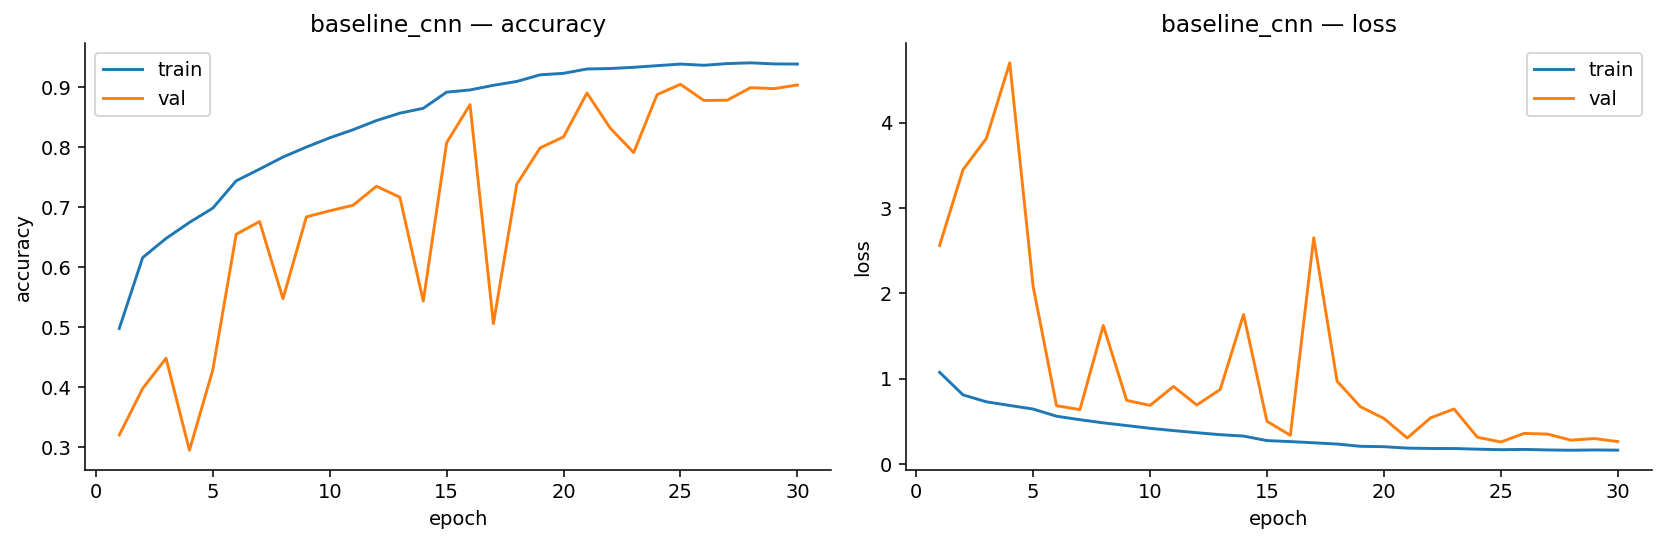

In [9]:
from IPython.display import Image as IPyImage
from src.config import FIGURES_DIR
IPyImage(filename=str(FIGURES_DIR / f"{MODEL_NAME}_training_curves.png"))


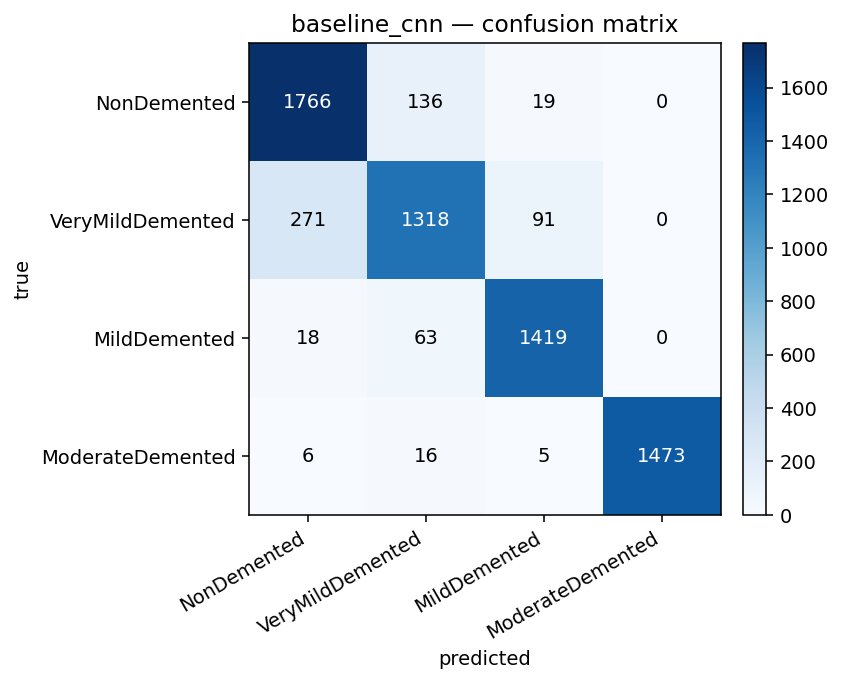

In [10]:
IPyImage(filename=str(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix.png"))


## 5. Per-class scores

Accuracy alone hides the class-imbalance picture. Per-class precision / recall / F1 tell us where the model is actually struggling.

In [11]:
import pandas as pd
per = metrics["per_class"]
pd.DataFrame({
    "class": per["labels"],
    "precision": [round(v, 4) for v in per["precision"]],
    "recall":    [round(v, 4) for v in per["recall"]],
    "f1":        [round(v, 4) for v in per["f1"]],
})


,class,precision,recall,f1
0,NonDemented,0.8569,0.9193,0.8870
1,VeryMildDemented,0.8598,0.7845,0.8204
2,MildDemented,0.9250,0.9460,0.9354
3,ModerateDemented,1.0000,0.9820,0.9909


## 6. Conclusion for Day 3

After full training (run on Colab GPU), expectations:
* The custom CNN typically reaches **>0.9 test accuracy** on this dataset because
  upsampled augmented copies make the task easier than a held-out clinical evaluation.
* The hardest pair to separate is usually **VeryMildDemented vs MildDemented** —
  expect off-diagonal cells there in the confusion matrix.

What gets persisted for the comparison notebook:
* `outputs/models/baseline_cnn.keras` — best weights.
* `outputs/predictions/baseline_cnn_test_predictions.npz` — y_true / y_pred / y_proba.
* `outputs/predictions/baseline_cnn_metrics.json` — accuracy / precision / recall / F1
  (macro and per-class) + confusion matrix + training info.
* `outputs/figures/baseline_cnn_training_curves.png` and `..._confusion_matrix.png`.

Next: **04_model_b_mobilenetv2.ipynb** — does a pretrained backbone help?
